# Подготовка формата данных

В файле ```landmarks_data_wiki.json``` собраны данные о достопримечательностях. Формат хранения данных следующий:
* ```wikidata_id``` - код объекта на wikidata
* ```name_en``` - название достопримечательности на английском
* ```name_ru``` - название достопримечательности на русском
* ```name_de``` - название достопримечательности на немецком
* ```wikidata_description_en``` - краткое описание на английском из wikidata
* ```wikidata_description_ru``` - краткое описание на русском из wikidata
* ```coordinates```:
  - ```latitude``` - широта
  - ```longitude``` - долгота
* ```city_ru``` - название региона, города или района на русском
* ```city_en``` - название региона, города или района на английском
* ```year_built``` - год постройки
* ```country_en``` - название страны на английском
* ```country_ru``` - название страны на русском
* ```architect_ru``` - имя архитектора на русском
* ```architect_en``` - имя архитектора на английском
* ```architectural_style_ru``` - архитектурный стиль на русском
* ```architectural_style_en``` - архитектурный стиль на английском
* ```heritage_status_ru``` - статус достопримечательности на русском
* ```heritage_status_en``` - статус достопримечательности на английском
* ```website``` - ссфлка на сайт достопримечательности
* ```wikipedia_url_en``` - ссылка на статью в wikipedia на английском
* ```wikipedia_url_ru``` - ссылка на статью в wikipedia на русском
* ```wikipedia_url_de``` - ссылка на статью в wikipedia на немецком
* ```landmark_type```:
  -  ```ru``` - тип достопримечательности на русском с Wikidata
  - ```en``` - тип достопримечательности на английском с Wikidata
  - ```type_id``` - тип достопримечательности на русском
* ```wikipedia_summary_en``` - описание достопримечательности с wikipedia на русском
* ```wikipedia_summary_ru``` - описание достопримечательности с wikipedia на английском
* ```wikipedia_summary_de``` - описание достопримечательности с wikipedia на немецком
* ```url``` - ссылка на достопримечательность на Wikidata
* ```landmark_id``` - id соответсвующее id достопримечательности из датасета Google Landmarks V2
* ```hierarchical_label``` - тип достопримечательности из датасета Google Landmarks V2


Необходимо скачать изображения, соответствующие выбранным достопримечательностям, и добавить в данные поле ```image_path```, ```ground_truth``` будет соответствовать агрегированной информации из полей ```wikipedia_summary_..```, ```heritage_status_..```, ```year_built```, ```architect_..```, ```architectural_style_..```

```python
example_data = [
  {
    "image_path": "/content/anowds3mbfkkwcosk4wcsssgo.jpg",
    "ground_truth": "Московский Кремль — древнейшая часть Москвы, охраняемый архитектурный ансамбль. Включает Успенский собор, где coronation царей происходило. Был резиденцией российских императоров и советских лидеров.",
    "name": "Московский Кремль"
  }
]
```
**Изображения счкачиваются в** ```download_images.py```

In [6]:
import json
import pandas as pd
import ast
import os
from tqdm import tqdm

In [5]:
LAND_PATH = "/Users/anastasiya/Documents/AITourGuide/setup_data_v3/data/landmarks_data_wiki.json"
TRAIN_PATH = "/Users/anastasiya/Documents/AITourGuide/data/train/train.csv"
IMAGES_DIR = "/Users/anastasiya/Documents/AITourGuide/images"

In [6]:
# загружаем json с отфильтрованными достопримечательностями и их описанием
# логика сбора данных: ...
with open(LAND_PATH, mode='r', encoding='utf-8') as f:
    data = json.load(f)

In [7]:
# пример отфильрованных данных
data[0]

{'wikidata_id': 'Q78',
 'name_en': 'Basel',
 'name_ru': 'Базель',
 'name_de': 'Basel',
 'wikidata_description_en': 'city on the Rhine in Switzerland',
 'wikidata_description_ru': 'город в Швейцарии, административный центр полукантона Базель-Штадт',
 'coordinates': {'latitude': 47.560555555556, 'longitude': 7.5905555555556},
 'country_ru': 'Швейцария',
 'country_en': 'Switzerland',
 'city_ru': 'Базель-Штадт',
 'city_en': 'Canton of Basel-Stadt',
 'heritage_status_ru': 'Объекты культурного наследия Швейцарии',
 'heritage_status_en': 'Swiss townscape worthy of protection',
 'website': 'https://www.bs.ch/',
 'wikipedia_url_en': 'https://en.wikipedia.org/wiki/Basel',
 'wikipedia_url_ru': 'https://ru.wikipedia.org/wiki/Базель',
 'wikipedia_url_de': 'https://de.wikipedia.org/wiki/Basel',
 'landmark_type': {'ru': 'достопримечательность',
  'en': 'landmark',
  'type_id': 'landmark'},
 'wikipedia_summary_en': "Basel ( BAH-zəl; German: [ˈbaːzl̩] ), also known as Basle (English:  BAHL), is a city 

In [5]:
# загружаем Google датасет со всеми достопримечательностями (id и ссылка на изображение)
train_df = pd.read_csv(TRAIN_PATH)

In [6]:
train_df.head()

,id,url,landmark_id
0,6e158a47eb2ca3f6,https://upload.wikimedia.org/wikipedia/commons...,142820
1,202cd79556f30760,http://upload.wikimedia.org/wikipedia/commons/...,104169
2,3ad87684c99c06e1,http://upload.wikimedia.org/wikipedia/commons/...,37914
3,e7f70e9c61e66af3,https://upload.wikimedia.org/wikipedia/commons...,102140
4,4072182eddd0100e,https://upload.wikimedia.org/wikipedia/commons...,2474


In [7]:
# лист с id достопримечательностей
collected_landmark_id = [landmark['landmark_id'] for landmark in data]
# датафрейм со ссылками на выбранные достопримечательности
df_collected_landmark_id_imgs = train_df[train_df.landmark_id.isin(collected_landmark_id)].copy()

In [8]:
df_collected_landmark_id_imgs = df_collected_landmark_id_imgs.sort_values(['landmark_id', 'url'])
df_collected_landmark_id_imgs['name'] = df_collected_landmark_id_imgs.groupby('landmark_id').cumcount() + 1
df_collected_landmark_id_imgs['name'] = df_collected_landmark_id_imgs['landmark_id'].astype(str) + '_' + df_collected_landmark_id_imgs['name'].astype(str) + '.jpg'

In [9]:
df_collected_landmark_id_imgs_gr = df_collected_landmark_id_imgs.groupby('landmark_id', as_index=False).agg({'url': list, 'name': list})

In [10]:
df_collected_landmark_id_imgs_gr.head()

,landmark_id,url,name
0,10,[http://upload.wikimedia.org/wikipedia/commons...,"[10_1.jpg, 10_2.jpg, 10_3.jpg, 10_4.jpg, 10_5...."
1,14,[https://upload.wikimedia.org/wikipedia/common...,"[14_1.jpg, 14_2.jpg]"
2,18,[http://upload.wikimedia.org/wikipedia/commons...,"[18_1.jpg, 18_2.jpg, 18_3.jpg, 18_4.jpg, 18_5...."
3,22,[http://upload.wikimedia.org/wikipedia/commons...,"[22_1.jpg, 22_2.jpg, 22_3.jpg, 22_4.jpg, 22_5...."
4,25,[http://upload.wikimedia.org/wikipedia/commons...,"[25_1.jpg, 25_2.jpg, 25_3.jpg, 25_4.jpg, 25_5...."


In [12]:
df_collected_landmark_id_imgs_gr.shape

(52267, 3)

In [ ]:
# Скачиваем изображения на основе df_collected_landmark_id_imgs_gr.csv
df_collected_landmark_id_imgs_gr.to_csv('data/df_collected_landmark_id_imgs_gr.csv', index=False)

# Клеим к данным image_path

Оставляем только примеры с изображениями и не пустым описанием

In [2]:
df_collected_landmark_id_imgs_gr = pd.read_csv('data/df_collected_landmark_id_imgs_gr.csv')
df_collected_landmark_id_imgs_gr.head()

,landmark_id,url,name
0,10,['http://upload.wikimedia.org/wikipedia/common...,"['10_1.jpg', '10_2.jpg', '10_3.jpg', '10_4.jpg..."
1,14,['https://upload.wikimedia.org/wikipedia/commo...,"['14_1.jpg', '14_2.jpg']"
2,18,['http://upload.wikimedia.org/wikipedia/common...,"['18_1.jpg', '18_2.jpg', '18_3.jpg', '18_4.jpg..."
3,22,['http://upload.wikimedia.org/wikipedia/common...,"['22_1.jpg', '22_2.jpg', '22_3.jpg', '22_4.jpg..."
4,25,['http://upload.wikimedia.org/wikipedia/common...,"['25_1.jpg', '25_2.jpg', '25_3.jpg', '25_4.jpg..."


In [8]:
data_with_img = []
for landmark in tqdm(data):
    image_names = df_collected_landmark_id_imgs_gr[df_collected_landmark_id_imgs_gr['landmark_id'] == landmark['landmark_id']]['name'].values[0]
    image_names = ast.literal_eval(image_names)
    
    # Фильтрация существующих изображений
    existing_images = [img for img in image_names 
                      if os.path.exists(os.path.join(IMAGES_DIR, img))]
    
    if len(existing_images) > 0 \
    and landmark.get('wikipedia_summary_en', None) is not None \
        and landmark.get('name_ru', landmark.get('name_en')) is not None:
        landmark['image_path'] = existing_images
        data_with_img.append(landmark)


100%|██████████| 52267/52267 [01:14<00:00, 705.55it/s]


In [9]:
data_with_img[0]

{'wikidata_id': 'Q78',
 'name_en': 'Basel',
 'name_ru': 'Базель',
 'name_de': 'Basel',
 'wikidata_description_en': 'city on the Rhine in Switzerland',
 'wikidata_description_ru': 'город в Швейцарии, административный центр полукантона Базель-Штадт',
 'coordinates': {'latitude': 47.560555555556, 'longitude': 7.5905555555556},
 'country_ru': 'Швейцария',
 'country_en': 'Switzerland',
 'city_ru': 'Базель-Штадт',
 'city_en': 'Canton of Basel-Stadt',
 'heritage_status_ru': 'Объекты культурного наследия Швейцарии',
 'heritage_status_en': 'Swiss townscape worthy of protection',
 'website': 'https://www.bs.ch/',
 'wikipedia_url_en': 'https://en.wikipedia.org/wiki/Basel',
 'wikipedia_url_ru': 'https://ru.wikipedia.org/wiki/Базель',
 'wikipedia_url_de': 'https://de.wikipedia.org/wiki/Basel',
 'landmark_type': {'ru': 'достопримечательность',
  'en': 'landmark',
  'type_id': 'landmark'},
 'wikipedia_summary_en': "Basel ( BAH-zəl; German: [ˈbaːzl̩] ), also known as Basle (English:  BAHL), is a city 

In [10]:
with open('data/landmarks_data_wiki_with_img.json', mode='w', encoding='utf-8') as f:
    json.dump(data_with_img, f, ensure_ascii=False, indent=2)

In [12]:
print(f"Количество собранных достопримечательностей с фото {len(data_with_img)}")
print(f"Доля собранных достопримечательностей с фото {round(len(data_with_img)/len(data)*100, 2)}%")

Количество собранных достопримечательностей с фото 33503
Доля собранных достопримечательностей с фото 64.1%


Далее landmarks_data_wiki_with_img.json отправляем на фильтрацию описанийи фото

## Убираем сэмплы с пустыи полями перед финальным сплитом

In [2]:
with open('/Users/anastasiya/Documents/AITourGuide/data/processed/landmarks_with_guide_descriptions.json', mode='r', encoding='utf-8') as f:
    data = json.load(f)

In [63]:
import re

def has_russian_letters(text: str) -> bool:
    # ищет любую русскую букву (строчную, заглавную или ё/Ё)
    return bool(re.search(r'[а-яА-ЯёЁ]', text))

In [64]:
finall_full_dataset = []
bad_landmarks = []
for landmark in tqdm(data):
    name = landmark.get("name_ru", landmark.get("name_en")) is not None
    valid_images = landmark.get("valid_images") is not None and len(landmark.get("valid_images")) > 0
    caption = landmark.get("landmark_summary_caption") is not None and len(landmark.get("landmark_summary_caption")) > 0
    chek_guide_description = landmark.get("guide_description") is not None and len(landmark.get("guide_description")) > 65 and has_russian_letters(landmark.get("guide_description"))
    guide_description = landmark.get("guide_description") if chek_guide_description else landmark.get("wikipedia_summary_ru")
    chek_guide_description = chek_guide_description if chek_guide_description else guide_description is not None and len(guide_description) > 0
    if name and caption and chek_guide_description and valid_images:
        # landmark["guide_description"] = guide_description
        finall_full_dataset.append(landmark)
    else:
        bad_landmarks.append(landmark)

100%|██████████| 23422/23422 [00:00<00:00, 168721.88it/s]


In [65]:
len(finall_full_dataset), len(bad_landmarks)

(21894, 1528)

In [ ]:
with open('/Users/anastasiya/Documents/AITourGuide/data/processed/landmarks_with_guide_descriptions_filtred.json', mode='w', encoding='utf-8') as f:
    json.dump(finall_full_dataset, f, ensure_ascii=False, indent=2)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_json("/Users/anastasiya/Documents/AITourGuide/data/processed/landmarks_with_guide_descriptions_filtred.json")

In [17]:
data.head()


,wikidata_id,name_en,name_ru,name_de,wikidata_description_en,wikidata_description_ru,coordinates,year_built,country_ru,country_en,...,wikipedia_summary_ru,wikipedia_summary_de,url,landmark_id,hierarchical_label,valid_images,invalid_images,landmark_summary_caption,guide_description,count_img
0,Q193369,Prague Castle,Пражский Град,Prager Burg,"castle complex in Prague, Czech Republic, dati...",крупная средневековая крепость в Праге,"{'latitude': 50.09, 'longitude': 14.4}",900,Чехия,Czech Republic,...,Пра́жский Град (чеш. Pražský hrad) — крепость ...,Die Prager Burg (tschechisch Pražský hrad) ist...,http://commons.wikimedia.org/wiki/Category:Sta...,21789,sculpture,"[{'path': '21789_1.jpg', 'confidence': 'high',...","[{'path': '21789_3.jpg', 'reason': 'vlm_reject...","A grand, golden-yellow building presents a dis...",Представьте себе: перед вами — величественный ...,3
1,Q2240953,Fallersleben Castle,NaN,Schloss Fallersleben,"castle in Wolfsburg, Germany",NaN,"{'latitude': 52.4171, 'longitude': 10.7165}",NaN,Германия,Germany,...,NaN,Schloss Fallersleben im Wolfsburger Stadtteil ...,http://commons.wikimedia.org/wiki/Category:Sch...,76707,castle / fort,"[{'path': '76707_2.jpg', 'confidence': 'high',...","[{'path': '76707_1.jpg', 'reason': 'vlm_reject...",A traditional European building showcases a re...,"Представьте себе тихий уголок Вольфсбурга, где...",2
2,Q6787059,Mathews Bridge,NaN,NaN,"bridge in Jacksonville, Florida, United States",NaN,"{'latitude': 30.327, 'longitude': -81.618}",NaN,США,United States,...,NaN,NaN,http://commons.wikimedia.org/wiki/Category:Mat...,132993,bridge,"[{'path': '132993_1.jpg', 'confidence': 'high'...",[],A multi-level structure showcases a dominant c...,Представьте себе: перед вами широкая река Сент...,5
3,Q7592425,St Andrew Undershaft,Церковь Святого Андрея (Олдгейт),NaN,"church in City of London, UK",NaN,"{'latitude': 51.513661111111, 'longitude': -0....",1520,Великобритания,United Kingdom,...,Церковь Святого Андрея (Сент-Эндрю Андершафт; ...,NaN,http://commons.wikimedia.org/wiki/Category:St_...,189386,church,"[{'path': '189386_1.jpg', 'confidence': 'high'...",[],A stone building showcases an arched window wi...,Представьте себе шумный Лондонский Сити — и по...,5
4,Q1708936,Loseley Park,NaN,Loseley Park,Grade I listed historic house museum in Arting...,NaN,"{'latitude': 51.2152, 'longitude': -0.6049}",1568,Великобритания,United Kingdom,...,NaN,Loseley Park ist ein historisches Herrenhaus a...,http://commons.wikimedia.org/wiki/Category:Los...,21800,museum,"[{'path': '21800_1.jpg', 'confidence': 'high',...","[{'path': '21800_2.jpg', 'reason': 'vlm_reject...","A grand, rectangular edifice boasts a symmetri...",Представьте себе тихую английскую глубинку: во...,3


In [16]:
data["count_img"] = data.apply(lambda x: len(x["valid_images"]), axis=1)

In [21]:
photo_count = data.groupby('count_img', as_index=False)["landmark_id"].count()

In [23]:
sum(photo_count['landmark_id'])

21894

In [24]:
photo_count

,count_img,landmark_id
0,1,2424
1,2,2941
2,3,3444
3,4,4839
4,5,8246


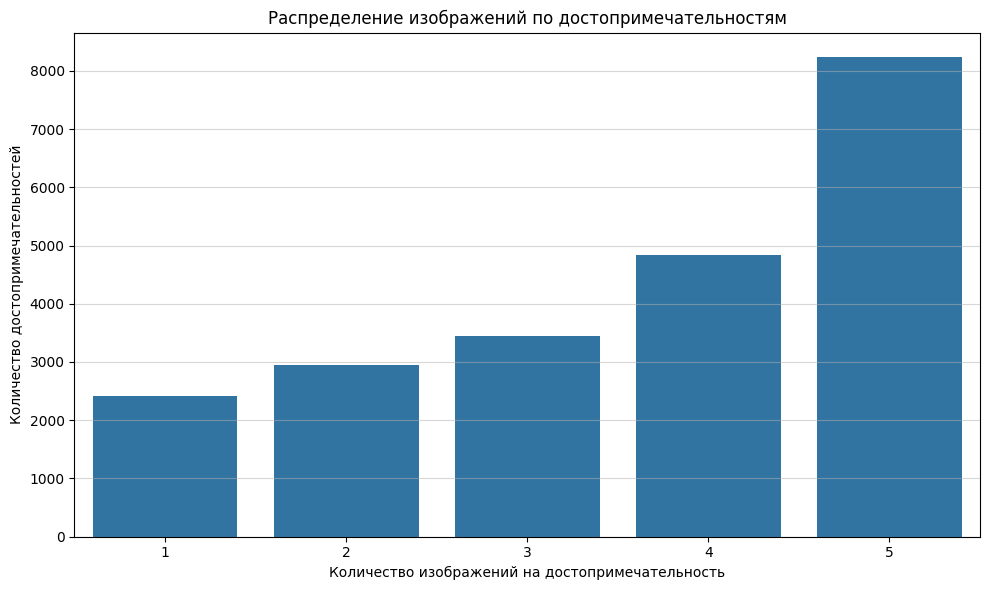

In [25]:
# Гистограмма: по оси X — количество изображений, по оси Y — число ландмарков
plt.figure(figsize=(10, 6))
sns.barplot(photo_count, x='count_img', y='landmark_id')
plt.xlabel('Количество изображений на достопримечательность')
plt.ylabel('Количество достопримечательностей')
plt.title('Распределение изображений по достопримечательностям')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [67]:
bad_landmarks[1500]

{'wikidata_id': 'Q2744462',
 'name_en': 'Belz Beis HaMedrash HaGadol',
 'name_de': 'Große Belzer Synagoge',
 'wikidata_description_en': 'Large Hasidic synagogue in Jerusalem',
 'coordinates': {'latitude': 31.79712222, 'longitude': 35.20760833},
 'year_built': '2002',
 'country_ru': 'Израиль',
 'country_en': 'Israel',
 'city_ru': 'Иерусалим',
 'city_en': 'Jerusalem',
 'architect_ru': ['Aaron Ostreicher'],
 'architect_en': ['Aaron Ostreicher'],
 'website': 'https://belz.org/see-the-shul',
 'wikipedia_url_en': 'https://en.wikipedia.org/wiki/Belz_Great_Synagogue',
 'landmark_type': {'ru': 'синагога', 'en': 'synagogue', 'type_id': 'синагога'},
 'wikipedia_summary_en': "The Belz Great Synagogue (Hebrew: בעלזא בית המדרש הגדול, romanized: Belz Beis HaMedrash HaGadol) is a Hasidic Jewish congregation and synagogue, located at 7 Binat Yisas'har Street, in the Kiryat Belz neighborhood of Jerusalem, Israel. Designed by Aaron Ostreicher and completed in 2002, the synagogue was built by the Belz Has

In [68]:
with open('/Users/anastasiya/Documents/AITourGuide/data/processed/landmarks_with_guide_descriptions_filtred.json', mode='w', encoding='utf-8') as f:
    json.dump(finall_full_dataset, f, ensure_ascii=False, indent=2)

In [1]:
import json

train_finaly_path = '/Users/anastasiya/Documents/AITourGuide/data/processed/train.jsonl'


In [4]:
with open(train_finaly_path, mode='r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        data = json.loads(line)
        break

In [5]:
data

{'image': '76707_2.jpg',
 'candidates': [{'name': 'Хоеннойфен',
   'caption': 'A robust stone fortress showcases a series of rectangular towers, each topped with flat roofs, lining its length. A dominant central tower emerges with larger size and intricate detailing. Rectangular walls punctuated by evenly-spaced windows flank the structure, leading to the main entrance via steps at ground level. \n\nA cylindrical tower with a flat top is encircled by rectangular walls, marked by a grand archway',
   'image': '76858_2.jpg',
   'type': 'semi_hard',
   'sim': 0.7670345902442932},
  {'name': 'Hauterive Monastery',
   'caption': 'A grand, rectangular edifice boasts a balanced façade with a central segment showcasing lofty arched windows and a triangular pediment upheld by columns. Decorative sculptures grace the roof, while the exterior is crafted from light-toned stone. This monumental structure is set amidst verdant gardens and trees, creating an idyllic setting.\n\nA towering multi-level